In [87]:
import pandas as pd
import numpy as np

# ================================
# Model Loading
# ================================
from joblib import load

# ================================
# Visualization
# ================================
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Evaluation Metrics
# ================================
from sklearn.metrics import (
    confusion_matrix,         
    accuracy_score,        
    precision_score,      
    recall_score,            
    f1_score,               
    classification_report,    
    precision_recall_curve,  
    roc_curve,              
    roc_auc_score            
)

In [88]:
pipeline = load("xgb_calibrated_pipeline.joblib")
print(type(pipeline))

<class 'sklearn.calibration.CalibratedClassifierCV'>


In [90]:
# Load Boston crime dataset
df_boston = pd.read_parquet("FeaturesDataset/BostonCrimeFeatures.parquet")
df_boston_actual = df_boston.target
df_la = pd.read_parquet("FeaturesDataset/LACrimeFeatures.parquet")
df_la_actual = df_la.target

In [92]:
feature_cols = ["is_afternoon_night","is_overnight","lag_1d","rolling_7d_mean_norm","rolling_30d_mean_norm",
                "tile_crime_density_percentile","tile_momentum","day_sin","day_cos","month_sin","month_cos","neighbor_lag_1d_norm"]
df_boston = df_boston[feature_cols].reset_index(drop=True)
df_la = df_la[feature_cols].reset_index(drop=True)

In [93]:
# Run predictions
pred_probs_boston = pipeline.predict_proba(df_boston) 
pred_labels_boston = pipeline.predict(df_boston)

pred_probs_la = pipeline.predict_proba(df_la) 
pred_labels_la = pipeline.predict(df_la)

In [107]:
df_boston_result = df_boston[['Predicted target','Predicted Probability','Actual target']]
min(df_boston_result.loc[df_boston_result['Predicted target'] == 1]['Predicted Probability'])

0.5253394246101379

In [94]:
# Attach predictions and actual target to DataFrame
df_boston["Predicted target"] = pred_labels_boston
df_boston["Predicted Probability"] = pred_probs_boston[:,1]
df_boston["Actual target"] = list(df_boston_actual)

df_la["Predicted target"] = pred_labels_la
df_la["Predicted Probability"] = pred_probs_la[:,1]
df_la["Actual target"] = list(df_la_actual)

In [95]:
# Function to calculate metrics and plot confusion matrix
def evaluate_predictions(y_true, y_pred, y_prob=None, title="Confusion Matrix"):
    # Calculate metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"Accuracy: {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall: {rec:.3f}")
    print(f"F1 Score: {f1:.3f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # 3️⃣ Plot confusion matrix with seaborn heatmap
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

# Visualization of Confusion Matrix Using Base Model

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def plot_confusion_matrix_base(y_true, y_pred, title):
    """
    Plot a clean, annotated confusion matrix with key metrics.
    """

    # ================================
    # 📊 Metrics
    # ================================
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # ================================
    # 🔢 Confusion Matrix
    # ================================
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Create annotated labels (like your fancy version)
    labels = np.array([
        [f"TN\n{tn}", f"FP\n{fp}"],
        [f"FN\n{fn}", f"TP\n{tp}"]
    ])

    # ================================
    # 🎨 Plot
    # ================================
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=False,
                xticklabels=["No Crime (0)", "Crime (1)"],
                yticklabels=["No Crime (0)", "Crime (1)"])

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(
        f"{title}\n\n"
        f"Accuracy: {acc:.3f} | Precision: {prec:.3f} | "
        f"Recall: {rec:.3f} | F1: {f1:.3f}",
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

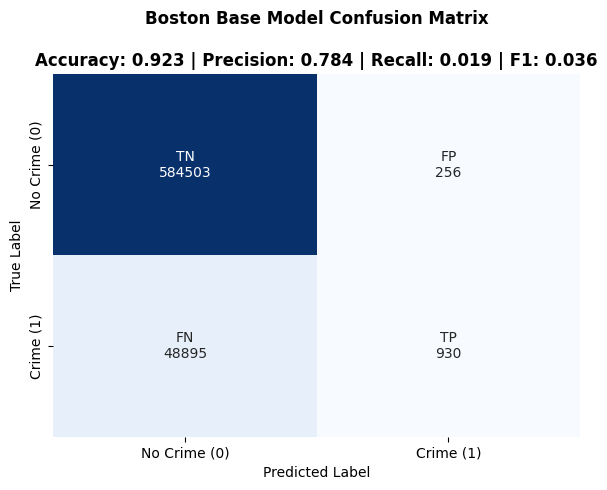

In [114]:
# Evaluate Boston
plot_confusion_matrix_base(
    y_true=df_boston["Actual target"], 
    y_pred=df_boston["Predicted target"],
    title="Boston Base Model Confusion Matrix" 
)

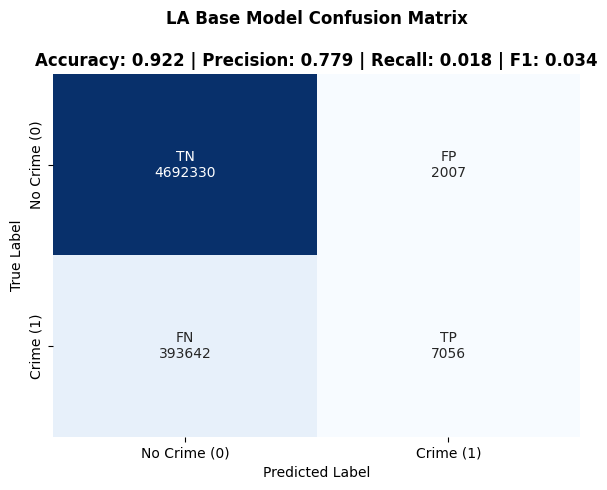

In [115]:
# Evaluate LA
plot_confusion_matrix_base(
    y_true=df_la["Actual target"], 
    y_pred=df_la["Predicted target"],
    title="LA Base Model Confusion Matrix" 
)

# Functions to Visualize Confusion Matrix, ROC AUC, and Evaluation Metrics Thresholding Effect

In [98]:
def plot_confusion_matrix(y_true, y_prob, threshold, model_name='Model', save_path=None):
    """
    Generate a detailed confusion matrix plot similar to your XGBoost template.

    Parameters:
        y_true (array-like): True binary labels
        y_prob (array-like): Predicted probabilities for positive class
        threshold (float): Probability threshold to classify positive
        model_name (str): Name to display on the figure
        save_path (str): Optional path to save the figure
    """
    # Predictions at threshold
    y_pred = (y_prob >= threshold).astype(int)
    
    # Base rate and confusion matrix
    BASE_RATE = y_true.mean()
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total = len(y_true)
    
    # Print text summary
    print("="*60)
    print(f"CONFUSION MATRIX — {model_name} @ Threshold {threshold}")
    print("="*60)
    print(f"\nRaw Counts:")
    print(f"   True Negatives  (TN): {tn:>10,}  correctly predicted no crime")
    print(f"   False Positives (FP): {fp:>10,}  predicted crime, no crime occurred")
    print(f"   False Negatives (FN): {fn:>10,}  missed crime events")
    print(f"   True Positives  (TP): {tp:>10,}  correctly predicted crime")
    print(f"\n   Total rows        : {total:,}")
    print(f"   Actual crime events : {tp+fn:,} ({BASE_RATE:.1%} base rate)")
    print(f"   Flagged shifts      : {tp+fp:,} ({(tp+fp)/total:.1%} of all shifts)")
    print(f"\nOperational Metrics:")
    print(f"   Precision  : {tp/(tp+fp) if (tp+fp)>0 else 0:.4f}")
    print(f"   Recall     : {tp/(tp+fn) if (tp+fn)>0 else 0:.4f}")
    print(f"   F1 Score   : {2*tp/(2*tp+fp+fn) if (2*tp+fp+fn)>0 else 0:.4f}")
    print(f"   Specificity: {tn/(tn+fp) if (tn+fp)>0 else 0:.4f}")
    print(f"   Lift       : {(tp/(tp+fp))/BASE_RATE if BASE_RATE>0 else np.nan:.2f}x vs {BASE_RATE:.1%} base rate")
    
    # Cell colors
    cell_colors = [['#D5E8D4', '#FFE6CC'], ['#F8CECC', '#DAE8FC']]
    cm_display = np.array([[tn, fp], [fn, tp]])
    quad_labels = [
        ['True Negative\n(Correctly cleared)',  'False Positive\n(Wasted dispatch)'],
        ['False Negative\n(Missed crime)',       'True Positive\n(Crime caught)']
    ]
    
    # Figure
    fig = plt.figure(figsize=(20, 7))
    fig.subplots_adjust(top=0.82, bottom=0.08, left=0.05,
                        right=0.97, wspace=0.40)
    
    # Suptitle
    fig.suptitle(
        f'Confusion Matrix Analysis — {model_name} @ Threshold {threshold}\n'
        f'Base Crime Rate: {BASE_RATE:.1%}  |  Total Shifts: {total:,}',
        fontweight='bold', fontsize=13, y=0.98
    )
    
    # ── Panel 1: Raw counts
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.set_xlim(-0.5, 1.5); ax1.set_ylim(-0.5, 1.5); ax1.set_aspect('equal')
    
    for i in range(2):
        for j in range(2):
            count = cm_display[i,j]
            pct = count/total
            ax1.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                                        facecolor=cell_colors[i][j], edgecolor='white', linewidth=3))
            ax1.text(j, i-0.10, f'{count:,}', ha='center', va='center',
                     fontsize=15, fontweight='bold', color='#2C3E50')
            ax1.text(j, i+0.18, f'({pct:.1%} of total)', ha='center', va='center',
                     fontsize=9, color='#555555')
            ax1.text(j, i+0.40, quad_labels[i][j], ha='center', va='center',
                     fontsize=7.5, color='#777777', style='italic')
    
    ax1.set_xticks([0,1])
    ax1.set_xticklabels(['Predicted\nNo Crime','Predicted\nCrime'], fontsize=10)
    ax1.xaxis.set_label_position('top'); ax1.xaxis.tick_top()
    ax1.set_yticks([0,1])
    ax1.set_yticklabels(['Actual\nNo Crime','Actual\nCrime'], fontsize=10)
    ax1.set_title('Raw Counts', fontweight='bold', fontsize=11, pad=45)
    
    # ── Panel 2: Row-normalized
    ax2 = fig.add_subplot(1, 3, 2)
    ax2.set_xlim(-0.5, 1.5); ax2.set_ylim(-0.5, 1.5); ax2.set_aspect('equal')
    
    cm_norm = cm_display.astype(float)
    cm_norm[0] /= cm_norm[0].sum() if cm_norm[0].sum()>0 else 1
    cm_norm[1] /= cm_norm[1].sum() if cm_norm[1].sum()>0 else 1
    norm_labels = [
        [f'{cm_norm[0,0]:.1%}\nSpecificity', f'{cm_norm[0,1]:.1%}\nFalse Alarm Rate'],
        [f'{cm_norm[1,0]:.1%}\nMiss Rate', f'{cm_norm[1,1]:.1%}\nRecall']
    ]
    
    for i in range(2):
        for j in range(2):
            ax2.add_patch(plt.Rectangle((j-0.5, i-0.5),1,1,
                                        facecolor=cell_colors[i][j], edgecolor='white', linewidth=3))
            ax2.text(j,i,norm_labels[i][j], ha='center', va='center', fontsize=12, fontweight='bold', color='#2C3E50')
    
    ax2.set_xticks([0,1])
    ax2.set_xticklabels(['Predicted\nNo Crime','Predicted\nCrime'], fontsize=10)
    ax2.xaxis.set_label_position('top'); ax2.xaxis.tick_top()
    ax2.set_yticks([0,1])
    ax2.set_yticklabels(['Actual\nNo Crime','Actual\nCrime'], fontsize=10)
    ax2.set_title('Row-Normalised\n(% within each actual class)', fontweight='bold', fontsize=11, pad=45)
    
    # ── Panel 3: Operational impact
    ax3 = fig.add_subplot(1, 3, 3)
    categories = ['Flagged shifts\n(model dispatches)','Actual crime\nevents','Crimes caught\nby model']
    values = [tp+fp, tp+fn, tp]
    bar_colors = ['#3498DB','#E74C3C','#2ECC71']
    bars = ax3.bar(categories, values, color=bar_colors, alpha=0.85, edgecolor='white', width=0.5)
    ax3.set_ylim(0, max(values)*1.30)
    
    annotations = [f"{tp+fp:,}\n({(tp+fp)/total:.1%})",
                   f"{tp+fn:,}\n({BASE_RATE:.1%})",
                   f"{tp:,}\n({tp/(tp+fn) if (tp+fn)>0 else 0:.1%})"]
    
    for bar, ann in zip(bars, annotations):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height()+max(values)*0.01, ann,
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax3.annotate(f'Precision lift:\n{(tp/(tp+fp))/BASE_RATE if BASE_RATE>0 else np.nan:.1f}x over\nrandom patrol',
                 xy=(0,tp+fp), xytext=(0.55, max(values)*1.10),
                 fontsize=9, color='#2C3E50',
                 bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF9C4', alpha=0.9),
                 arrowprops=dict(arrowstyle='->', color='#2C3E50'))
    
    ax3.set_ylabel('Number of Tile-Shifts', fontsize=10)
    ax3.set_title('Operational Impact\n(What the model does in practice)', fontweight='bold', fontsize=11)
    ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{int(val):,}'))
    ax3.grid(axis='y', alpha=0.3)
    
    plt.show()
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Crime','Crime'], digits=4))

In [99]:
def plot_precision_recall_vs_threshold(y_true, y_prob, chosen_threshold=0.15, 
                                       focus_range=(0.05, 0.40), name='Model'):
    """
    Plot Precision, Recall, and F1 as a function of probability threshold
    and check stability around a chosen threshold.

    Parameters:
        y_true (array-like): True binary labels
        y_prob (array-like): Predicted probabilities for positive class
        chosen_threshold (float): Threshold to highlight on the plot
        focus_range (tuple): X-axis range to zoom in on (min, max)
        name (str): Name of the model for titles and labels
    """
    # Compute precision, recall, thresholds
    precision_vals, recall_vals, thresholds = precision_recall_curve(y_true, y_prob)
    f1_vals = 2 * (precision_vals[:-1] * recall_vals[:-1]) / (precision_vals[:-1] + recall_vals[:-1] + 1e-9)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(thresholds, precision_vals[:-1], color='#E74C3C', linewidth=2, label='Precision')
    ax.plot(thresholds, recall_vals[:-1], color='#2ECC71', linewidth=2, label='Recall')
    ax.plot(thresholds, f1_vals, color='#3498DB', linewidth=2, label='F1')

    # Highlight chosen threshold
    ax.axvline(x=chosen_threshold, color='black', linestyle='--', linewidth=1.5,
               label=f'Chosen threshold ({chosen_threshold})')

    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.set_title(f'{name} — Precision, Recall, F1 vs Threshold\n'
                 f'Check stability around threshold {chosen_threshold}',
                 fontweight='bold')
    ax.legend()
    ax.set_xlim(focus_range)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Stability check around chosen threshold
    mask = (thresholds >= chosen_threshold - 0.02) & (thresholds <= chosen_threshold + 0.02)
    check_df = pd.DataFrame({
        'Threshold': thresholds[mask],
        'Precision': precision_vals[:-1][mask],
        'Recall'   : recall_vals[:-1][mask],
        'F1'       : f1_vals[mask]
    }).round(4)

    print(f"\nThreshold stability check ({chosen_threshold-0.02:.2f} – {chosen_threshold+0.02:.2f}):")
    print(check_df.to_string(index=False))
    print("\nIf precision and recall change smoothly across this range, "
          "the threshold is stable and safe to deploy.")

In [100]:
def plot_roc_auc(y_true, y_prob, chosen_threshold=None, name='Model'):
    """
    Plot ROC curve and display AUC score. Optionally mark a chosen threshold.
    
    Parameters:
        y_true (array-like): True binary labels
        y_prob (array-like): Predicted probabilities for positive class
        chosen_threshold (float, optional): Threshold to highlight on the curve
        name (str): Name of the model for title
    """
    # Compute ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    auc_score = roc_auc_score(y_true, y_prob)
    
    # Plot
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, color='#3498DB', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random chance')
    
    # Highlight chosen threshold if provided
    if chosen_threshold is not None:
        # Find closest threshold index
        idx = (np.abs(thresholds - chosen_threshold)).argmin()
        plt.scatter(fpr[idx], tpr[idx], color='red', s=80, zorder=5,
                    label=f'Threshold {chosen_threshold:.3f}')
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {name}', fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"AUC Score: {auc_score:.4f}")

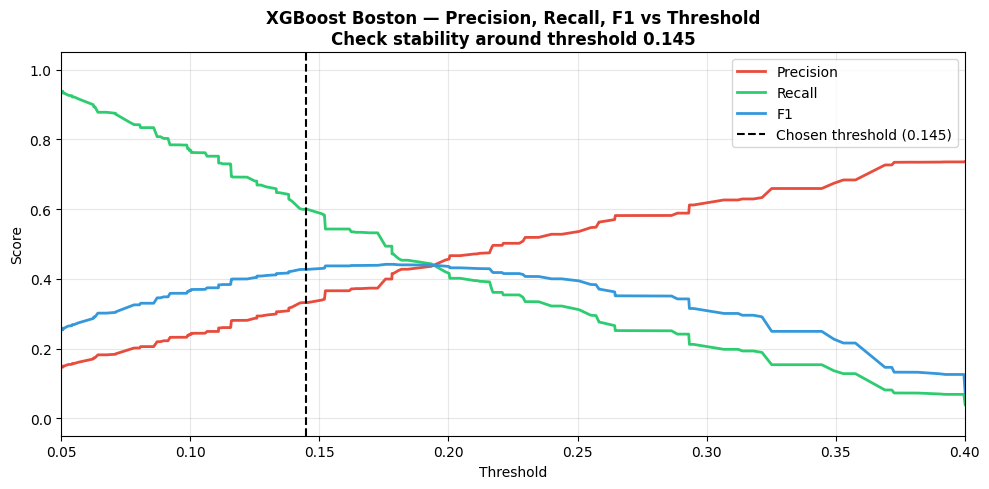


Threshold stability check (0.12 – 0.16):
 Threshold  Precision  Recall     F1
    0.1250     0.2871  0.6804 0.4038
    0.1254     0.2871  0.6803 0.4038
    0.1258     0.2871  0.6803 0.4038
    0.1258     0.2936  0.6689 0.4081
    0.1260     0.2936  0.6689 0.4081
    0.1274     0.2936  0.6689 0.4081
    0.1296     0.2966  0.6632 0.4099
    0.1298     0.2966  0.6632 0.4099
    0.1332     0.2993  0.6585 0.4115
    0.1334     0.3058  0.6473 0.4154
    0.1335     0.3058  0.6473 0.4154
    0.1343     0.3058  0.6473 0.4154
    0.1381     0.3085  0.6422 0.4168
    0.1382     0.3163  0.6282 0.4208
    0.1382     0.3163  0.6282 0.4208
    0.1394     0.3191  0.6227 0.4220
    0.1424     0.3309  0.6012 0.4268
    0.1436     0.3319  0.5993 0.4272
    0.1447     0.3319  0.5993 0.4272
    0.1449     0.3319  0.5993 0.4272
    0.1454     0.3319  0.5993 0.4272
    0.1512     0.3397  0.5859 0.4301
    0.1516     0.3414  0.5831 0.4306
    0.1518     0.3414  0.5831 0.4306
    0.1520     0.3414  0.5831 0.4

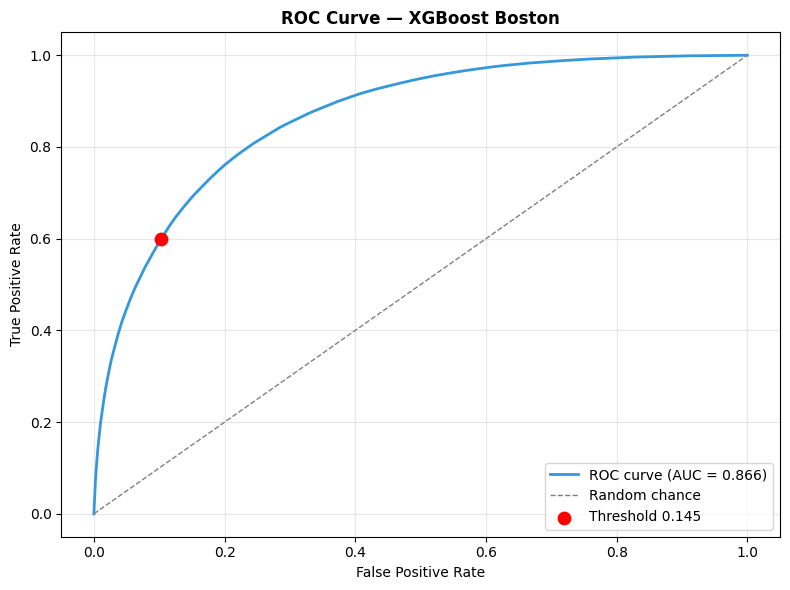

AUC Score: 0.8656
CONFUSION MATRIX — XGBoost Boston @ Threshold 0.15

Raw Counts:
   True Negatives  (TN):    528,019  correctly predicted no crime
   False Positives (FP):     56,740  predicted crime, no crime occurred
   False Negatives (FN):     20,634  missed crime events
   True Positives  (TP):     29,191  correctly predicted crime

   Total rows        : 634,584
   Actual crime events : 49,825 (7.9% base rate)
   Flagged shifts      : 85,931 (13.5% of all shifts)

Operational Metrics:
   Precision  : 0.3397
   Recall     : 0.5859
   F1 Score   : 0.4301
   Specificity: 0.9030
   Lift       : 4.33x vs 7.9% base rate


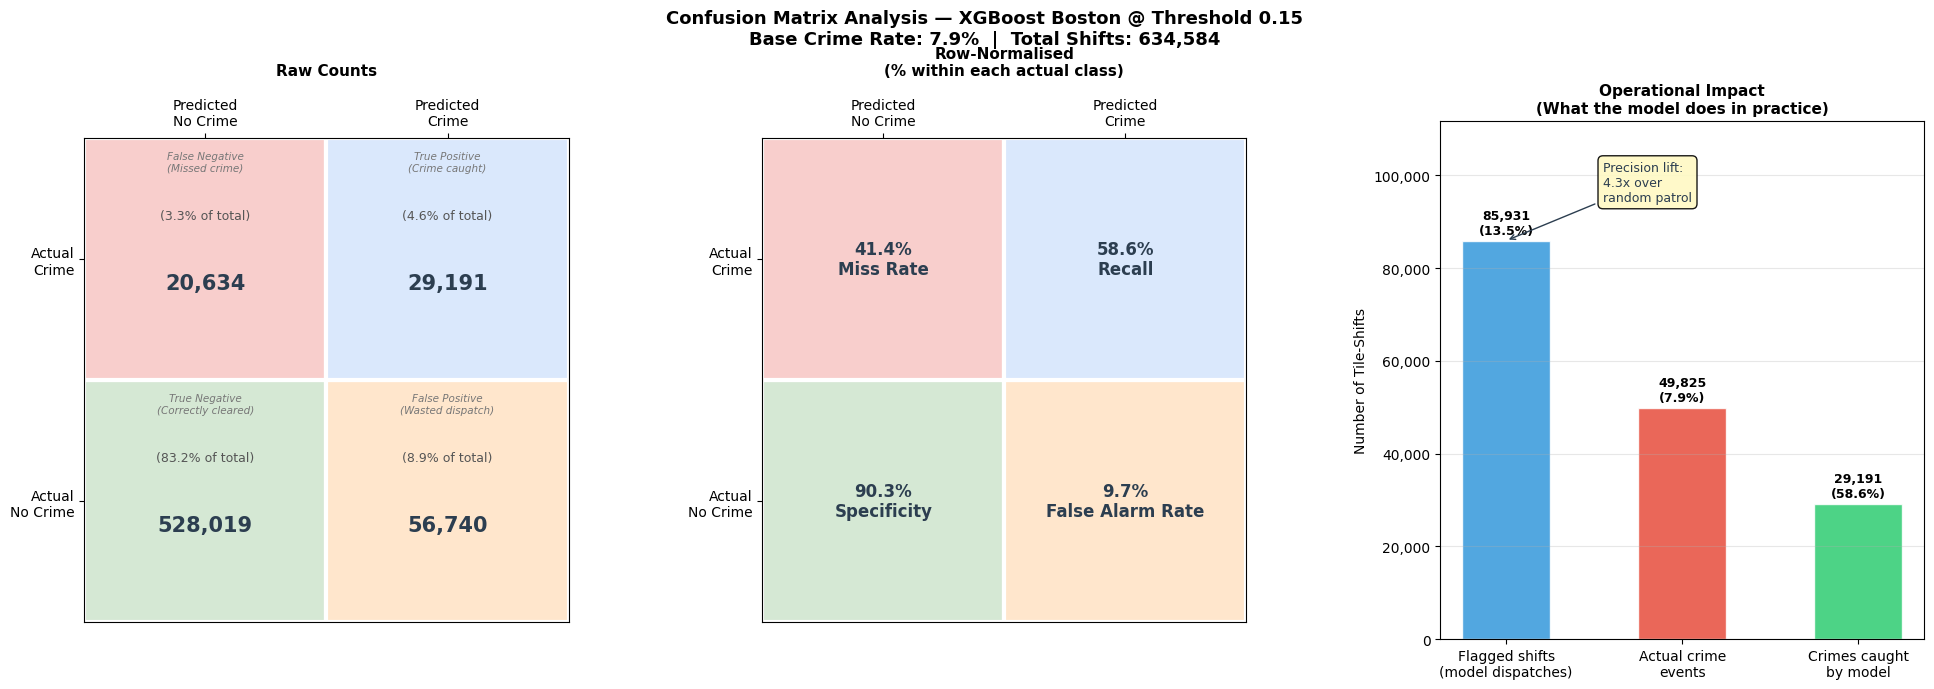


Classification Report:
              precision    recall  f1-score   support

    No Crime     0.9624    0.9030    0.9317    584759
       Crime     0.3397    0.5859    0.4301     49825

    accuracy                         0.8781    634584
   macro avg     0.6510    0.7444    0.6809    634584
weighted avg     0.9135    0.8781    0.8923    634584



In [101]:
boston_threshold = 0.145
y_true = df_boston['Actual target']
y_prob = df_boston['Predicted Probability']

plot_precision_recall_vs_threshold(y_true, y_prob, chosen_threshold=0.145, name='XGBoost Boston')
plot_roc_auc(y_true, y_prob, chosen_threshold=0.145, name='XGBoost Boston')
plot_confusion_matrix(y_true, y_prob, threshold=0.15, model_name='XGBoost Boston')

# LA Model Evaluation Result

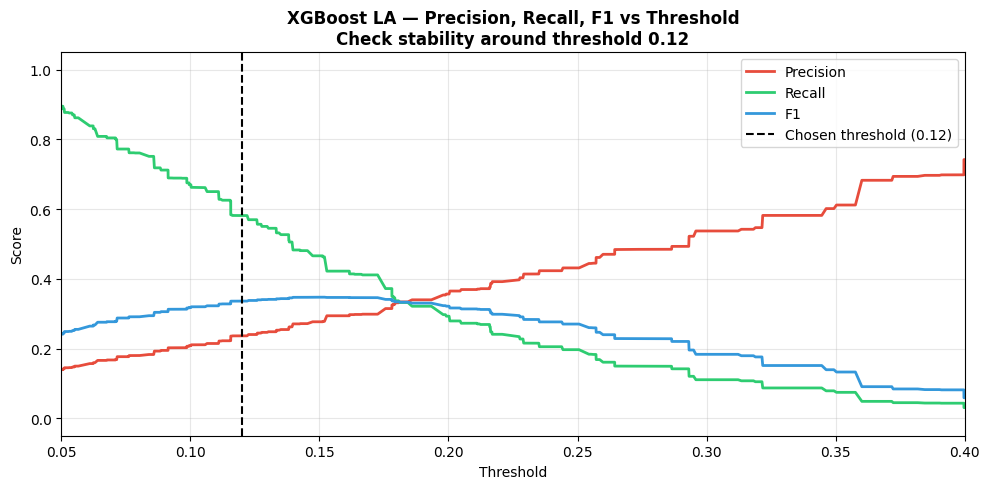


Threshold stability check (0.10 – 0.14):
 Threshold  Precision  Recall     F1
    0.1001     0.2083  0.6697 0.3178
    0.1001     0.2083  0.6697 0.3178
    0.1002     0.2083  0.6697 0.3178
    0.1002     0.2083  0.6697 0.3178
    0.1003     0.2107  0.6622 0.3197
    0.1003     0.2107  0.6622 0.3197
    0.1007     0.2107  0.6622 0.3197
    0.1048     0.2109  0.6615 0.3199
    0.1052     0.2109  0.6615 0.3199
    0.1057     0.2109  0.6615 0.3199
    0.1065     0.2145  0.6501 0.3226
    0.1082     0.2145  0.6501 0.3226
    0.1084     0.2145  0.6501 0.3226
    0.1087     0.2145  0.6501 0.3226
    0.1097     0.2145  0.6501 0.3226
    0.1099     0.2145  0.6500 0.3226
    0.1102     0.2145  0.6500 0.3226
    0.1107     0.2145  0.6500 0.3226
    0.1109     0.2145  0.6500 0.3226
    0.1111     0.2216  0.6279 0.3276
    0.1118     0.2216  0.6279 0.3276
    0.1124     0.2223  0.6254 0.3280
    0.1130     0.2223  0.6254 0.3280
    0.1147     0.2223  0.6254 0.3280
    0.1153     0.2223  0.6254 0.3

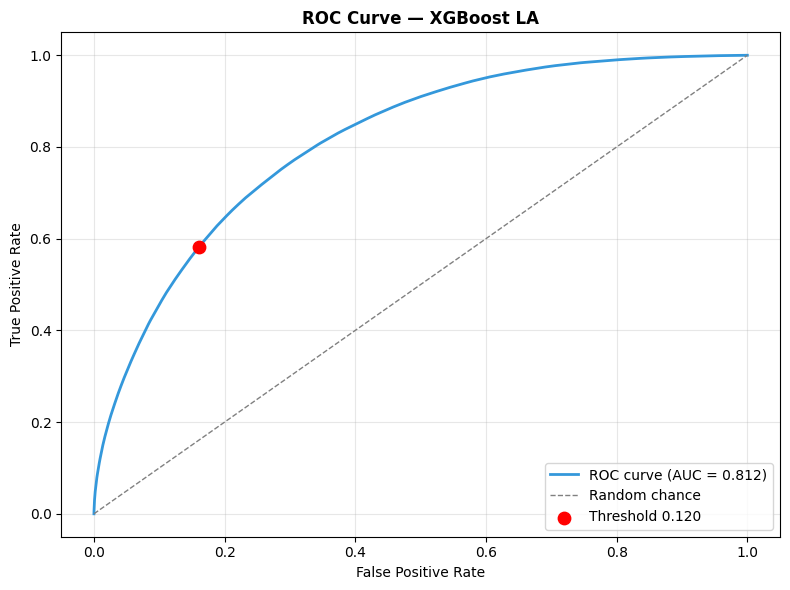

AUC Score: 0.8124
CONFUSION MATRIX — XGBoost LA @ Threshold 0.15

Raw Counts:
   True Negatives  (TN):  4,206,511  correctly predicted no crime
   False Positives (FP):    487,826  predicted crime, no crime occurred
   False Negatives (FN):    214,019  missed crime events
   True Positives  (TP):    186,679  correctly predicted crime

   Total rows        : 5,095,035
   Actual crime events : 400,698 (7.9% base rate)
   Flagged shifts      : 674,505 (13.2% of all shifts)

Operational Metrics:
   Precision  : 0.2768
   Recall     : 0.4659
   F1 Score   : 0.3472
   Specificity: 0.8961
   Lift       : 3.52x vs 7.9% base rate


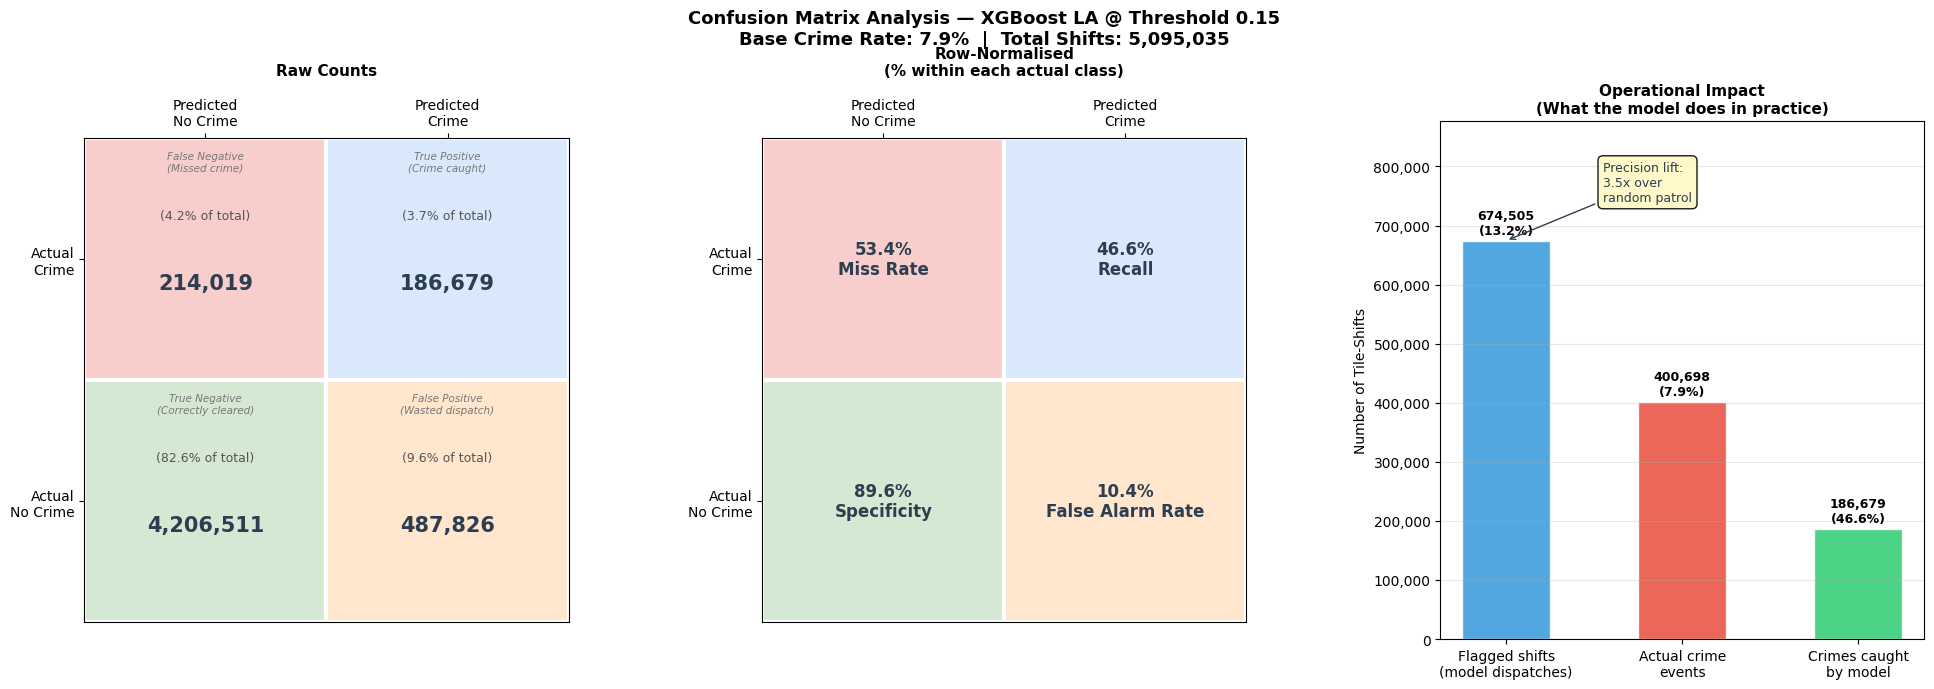


Classification Report:
              precision    recall  f1-score   support

    No Crime     0.9516    0.8961    0.9230   4694337
       Crime     0.2768    0.4659    0.3472    400698

    accuracy                         0.8622   5095035
   macro avg     0.6142    0.6810    0.6351   5095035
weighted avg     0.8985    0.8622    0.8777   5095035



In [104]:
la_threshold = 0.12

y_true = df_la['Actual target']
y_prob = df_la['Predicted Probability']

plot_precision_recall_vs_threshold(y_true, y_prob, chosen_threshold=la_threshold, name='XGBoost LA')
plot_roc_auc(y_true, y_prob, chosen_threshold=0.12, name='XGBoost LA')
plot_confusion_matrix(y_true, y_prob, threshold=0.15, model_name='XGBoost LA')